# Task Arithmetic — Mask Calibration (Direct Imports)
Notebook mínimo para testar **calibração de máscara multi-round** usando **imports diretos** dos módulos do repositório.


In [1]:
# --- 0) Runtime check ---
import torch, sys, os
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.9.0+cu126
cuda available: True
gpu: Tesla T4


In [3]:
# --- 1) Clone repo (task_arithmetic branch) ---
!git clone -b task_arithmetic --single-branch https://github.com/caiopenayo/Federated-Learning-Under-the-Lens-of-Task-Arithmetic.git
%cd Federated-Learning-Under-the-Lens-of-Task-Arithmetic
!git pull origin task_arithmetic


# Make repo importable
repo_root = os.path.abspath(".")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

Cloning into 'Federated-Learning-Under-the-Lens-of-Task-Arithmetic'...
remote: Enumerating objects: 150, done.
remote: Counting objects: 100% (150/150), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 150 (delta 49), reused 95 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (150/150), 175.36 KiB | 9.23 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/Federated-Learning-Under-the-Lens-of-Task-Arithmetic
From https://github.com/caiopenayo/Federated-Learning-Under-the-Lens-of-Task-Arithmetic
 * branch            task_arithmetic -> FETCH_HEAD
Already up to date.


In [2]:
# %cd /content
# !rm -rf Federated-Learning-Under-the-Lens-of-Task-Arithmetic
# !ls

/content
sample_data


## Imports


In [4]:
# --- 2) Direct imports ---
from optim.fisher import (
    calibrate_gradient_mask_multi_round,
    MaskCalibrationConfig,
    compute_fisher_diag_scores
)

from models.vit_dino import build_dino_vit
from fl.dataloaders import build_federated_dataloaders
from data.datasets import get_cifar100, get_cifar100_transforms
from data.partition import make_dataset_loaders
from fl.fedavg import run_fedavg_experiment


In [5]:
# --- 3) Build model ---
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_dino_vit(num_classes=100, img_size=160)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
print("model ready on", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

model ready on cuda


## Fine-tuning with Fisher algorithm and mask

> Add blockquote



In [6]:
# Loading data
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import numpy as np

transform_train, transform_test = get_cifar100_transforms(img_size=160)

train, val, test = get_cifar100(
    train_transform=transform_train,
    test_transform=transform_test,
    val_ratio=0.1,
    root="./data",
    seed=42
)

train_loader_centr, val_loader_centr, test_loader_centr = make_dataset_loaders(train, val, test)


img_size = 160
transform = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
])

train = torchvision.datasets.CIFAR100(
    root="./data", train=True, download=True, transform=transform
)

idx = np.random.RandomState(0).choice(len(train), size=1024, replace=False)
subset = Subset(train, idx)

loader = DataLoader(
    subset, batch_size=64, shuffle=True,
    num_workers=2, pin_memory=torch.cuda.is_available()
)

print("subset size:", len(subset))

100%|██████████| 169M/169M [00:04<00:00, 34.8MB/s]


subset size: 1024


In [7]:
cfg = MaskCalibrationConfig(
    trainable_fraction=0.10,
    rounds=3,
    fisher_batches_per_round=10,
    rule="least_sensitive",
)


mask = calibrate_gradient_mask_multi_round(
    model=model,
    dataloader=loader,
    criterion=criterion,
    device=device,
    cfg=cfg,
)

# Stats
total, trainable = 0, 0
for m in mask.values():
    total += m.numel()
    trainable += int((m != 0).sum())

print(f"Trainable params: {trainable:,} / {total:,} ({trainable/total:.2%})")

Trainable params: 2,166,730 / 21,667,300 (10.00%)


In [7]:

import numpy as np
import copy
import matplotlib.pyplot as plt

# Experiment Parameters
K = 100                 # Total clients
C = 0.1                 # Participation (10 clients/round)
Nc_values = [1, 5, 50]  # Heterogeneity levels
J_values = [4, 8, 16]   # Local steps

# NOTE: 40 rounds is very short for CIFAR-100.
# Real convergence usually needs 500+ rounds.
# We use small numbers here just to demonstrate the code runs.
BASE_ROUNDS = 40
BASE_J = 4

all_histories = {}

print("=== Starting Heterogeneity Experiments ===")

# 2. Run Non-IID with mask
for Nc in Nc_values:
    print(f"\n--- Non-IID: Nc={Nc} (Classes per client) ---")

    # Re-shard data for this specific Nc
    print(f"Generating dataloaders for Nc={Nc}...")

    # FIX: Use *_ to catch extra return values (stats, etc.)
    loaders_noniid, _, _, *_ = build_federated_dataloaders(
        train_transform=transform_train,
        test_transform=transform_test,
        K=K,
        sharding="non_iid",
        Nc=Nc,
        val_ratio=0.1,
        batch_size=64,
        seed=42
    )

    nc_results = {}
    for J in J_values:
        scaled_rounds = int(BASE_ROUNDS * (BASE_J / J))

        print(f"\n[Experiment] Non-IID (Nc={Nc}), J={J}, Rounds={scaled_rounds}")
        hist = run_fedavg_experiment(
            model, loaders_noniid, test_loader_centr,
            rounds=scaled_rounds, C=C, J=J, lr=0.01, device=device, log_every=5
        )
        nc_results[J] = hist

    all_histories[f'Nc={Nc}'] = nc_results

print("\n✓ Experiments Complete")

=== Starting Heterogeneity Experiments ===

--- Non-IID: Nc=1 (Classes per client) ---
Generating dataloaders for Nc=1...

[Experiment] Non-IID (Nc=1), J=4, Rounds=40
  [FedAvg] Start: 40 rounds, C=0.1 (10 clients/round from 100 eligible), J=4 steps
    Round 005 | Test Acc: 1.00% | Train Loss: 2.0700 | Trained clients: 10/10
    Round 010 | Test Acc: 1.06% | Train Loss: 1.8240 | Trained clients: 10/10
    Round 015 | Test Acc: 1.00% | Train Loss: 1.4660 | Trained clients: 10/10
    Round 020 | Test Acc: 1.52% | Train Loss: 1.2161 | Trained clients: 10/10
    Round 025 | Test Acc: 1.21% | Train Loss: 1.1915 | Trained clients: 10/10
    Round 030 | Test Acc: 1.00% | Train Loss: 1.2904 | Trained clients: 10/10
    Round 035 | Test Acc: 1.00% | Train Loss: 1.3141 | Trained clients: 10/10
    Round 040 | Test Acc: 1.00% | Train Loss: 1.3298 | Trained clients: 10/10

[Experiment] Non-IID (Nc=1), J=8, Rounds=20
  [FedAvg] Start: 20 rounds, C=0.1 (10 clients/round from 100 eligible), J=8 step

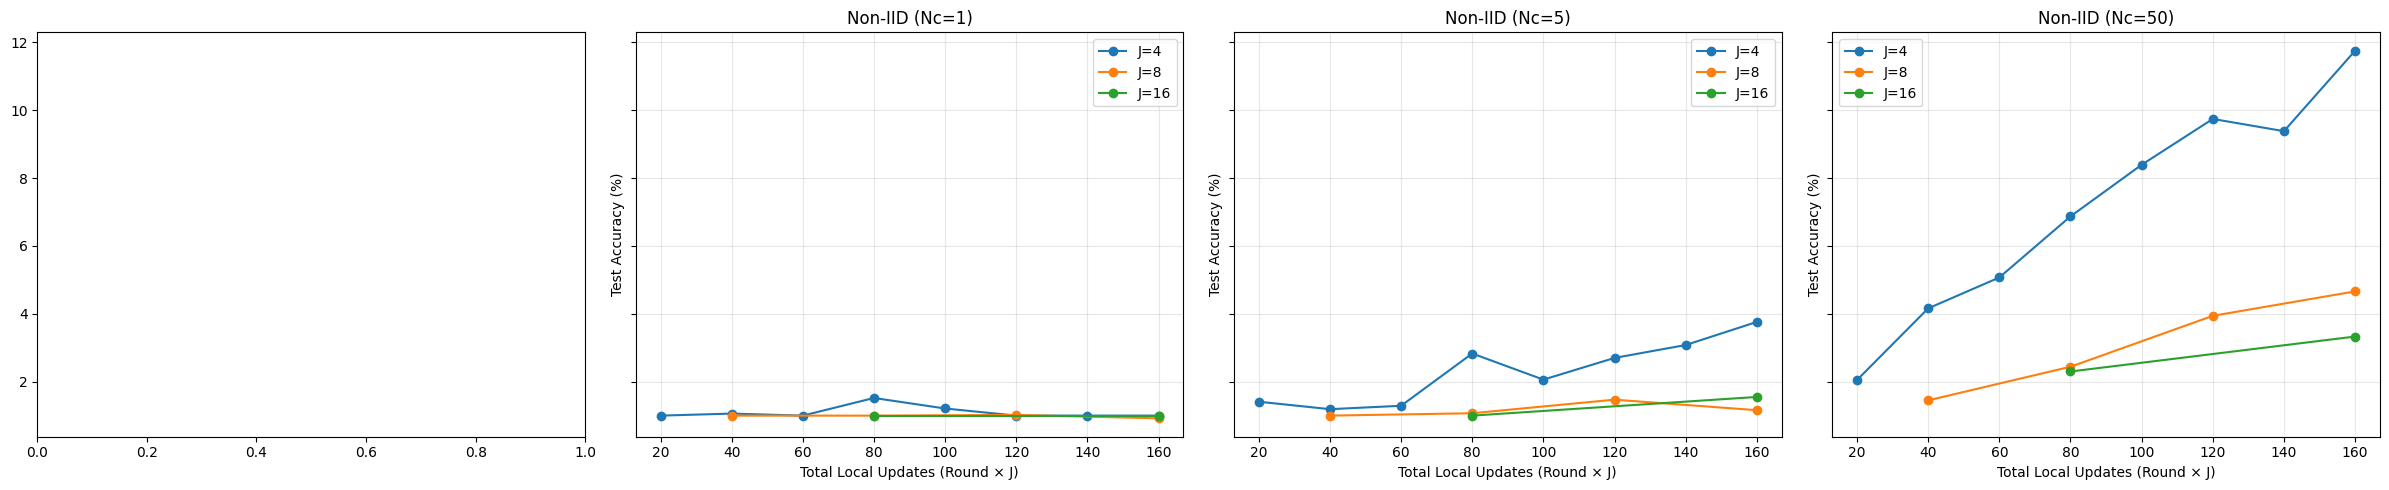

In [8]:
# Visualize the impact of Local Steps (J) across different distributions
fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharey=True)
titles = ["IID"] + [f"Non-IID (Nc={nc})" for nc in Nc_values]
keys = ['iid'] + [f'Nc={nc}' for nc in Nc_values]

for ax, key, title in zip(axes, keys, titles):
    if key not in all_histories: continue

    results = all_histories[key]
    for J, hist in results.items():
        # Plot Accuracy vs. Total Local Updates
        # This normalizes the x-axis so we compare "work done" fairly
        total_updates = [r * J for r in hist['rounds']]
        ax.plot(total_updates, hist['test_acc'], marker='o', label=f'J={J}')

    ax.set_title(title)
    ax.set_xlabel("Total Local Updates (Round × J)")
    ax.set_ylabel("Test Accuracy (%)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import inspect
print(inspect.signature(run_fedavg_experiment))
